# Many-body perturbation theory

Companion notebook to Chapter 9 of *Quantum mechanics for many-particle
systems*.  Every number quoted in the chapter is produced here; the code is
the same as in `BookManybody/BookPrograms/chapter09/mbpt.py`.

Everything is done in the determinant basis of Chapter 5, where $\hat H_0$ is
diagonal and the perturbation is the rest of the matrix.  With
$\hat R = \hat Q/(W_0-\hat H_0)$ the Rayleigh-Schrödinger series follows from

$$|\Psi^{(n)}\rangle = \hat R\Big[\hat H_I|\Psi^{(n-1)}\rangle
   - \sum_{k=1}^{n-1}\Delta E^{(k)}|\Psi^{(n-k)}\rangle\Big],
\qquad
\Delta E^{(n+1)} = \langle\Phi_0|\hat H_I|\Psi^{(n)}\rangle,$$

which reproduces the explicit first, second and third-order expressions and
continues to any order.

Contents:

1. The recursion against the explicit expressions
2. The pairing model
3. Higher order: does the series converge?
4. The Lipkin model
5. Size extensivity: Rayleigh-Schrödinger against Brillouin-Wigner
6. Brillouin-Wigner and its exact resummation
7. The Hubbard model
8. The pairing plus particle-hole model
9. Does the partition matter?
10. Everything against everything

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)
import mbpt

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. The recursion against the explicit expressions

$$\Delta E^{(1)} = V_{00},\qquad
\Delta E^{(2)} = \sum_{m\neq0}\frac{V_{0m}V_{m0}}{D_m},$$
$$\Delta E^{(3)} = \sum_{m,n\neq0}\frac{V_{0m}V_{mn}V_{n0}}{D_mD_n}
  - V_{00}\sum_{m\neq0}\frac{V_{0m}V_{m0}}{D_m^2}.$$

The second term of the third-order energy — the *renormalisation* term — is
the one to watch.  It is what makes the series size extensive.

In [2]:
mbpt.demo_recursion()

1. The recursion against the explicit expressions
The series can be generated by a recursion or written out term by
term.  They must agree, and the third-order agreement is the
interesting one, because it is there that the renormalisation
term first appears.

           model            E1            E2   E3 (recursion)   E3 (explicit)
         pairing   -0.50000000   -0.07291667      -0.01041667     -0.01041667
          Lipkin    0.00000000   -0.12000000       0.00000000      0.00000000
         Hubbard    3.00000000   -0.40277778       0.00000000      0.00000000
   pairing + p-h   -0.55000000   -0.08929167      -0.01386153     -0.01386153

The two pieces of the third-order term, for the pairing model at
g = 0.5:
   principal term    sum_mn V_0m V_mn V_n0 / D_m D_n  =  -0.02300347
   renormalisation   V_00 sum_m V_0m V_m0 / D_m^2     =  -0.01258681
   difference        Delta E^(3)                      =  -0.01041667

The renormalisation term is not a small correction here: it is
larg

## 2. The pairing model

Four doubly degenerate levels, four particles, $\xi=1$.  The energy through
first order is $2-g$, which is exactly the Hartree-Fock energy of Chapter 6 —
for this interaction the mean field does nothing, so everything beyond first
order is genuine correlation energy.

In [3]:
mbpt.demo_pairing()

2. The pairing model
Four doubly degenerate levels, four particles, xi = 1.  The
unperturbed reference energy is W_0 = 2 and the first-order energy
is -g, so E_ref = 2 - g, which is the Hartree-Fock energy of
chapter 6: the mean field does nothing for this interaction.

     g      E_ref          +E2          +E3          FCI          CID       HF+RPA
  0.25    1.75000   1.73177083   1.73046875   1.73045985   1.73050700   1.71634735


  0.50    1.50000   1.42708333   1.41666667   1.41677428   1.41759645   1.37450235
  1.00    1.00000   0.70833333   0.62500000   0.63554847   0.64890655   0.55458933


  1.50    0.50000  -0.15625000  -0.43750000  -0.34819051  -0.29113175  -0.40624787
  2.00    0.00000  -1.16666667  -1.83333333  -1.48965216  -1.35208670  -1.47622319

Second order already recovers most of the correlation energy and
third order improves on it, but the series is not variational:
nothing forbids it from crossing the exact answer, and at g = 2
it does.  Compare with CID, which is variational and therefore
always above, and with RPA, which sums a particular class of
contributions to all orders.


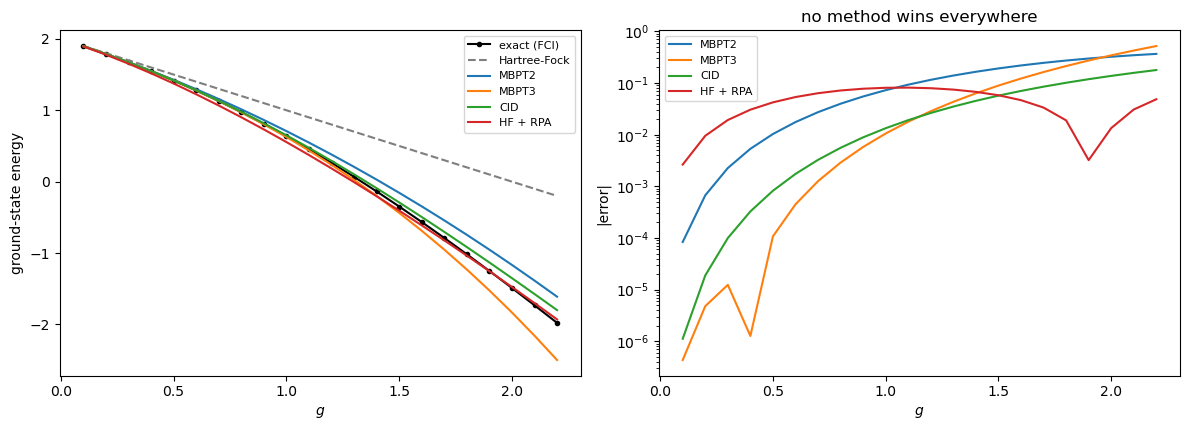

In [4]:
import rpa as rpamod
import fci

gs = np.linspace(0.1, 2.2, 22)
fock = rpamod.FockSpace(4)
ref, m2, m3, cid, rpa_e, exact = [], [], [], [], [], []
for g in gs:
    part, model = mbpt.pairing_partition(g=g)
    e = mbpt.rayleigh_schrodinger(part, order=3)
    r0 = part.reference_energy
    ref.append(r0); m2.append(r0 + e[1]); m3.append(r0 + e[1] + e[2])
    cid.append(model.energies(2)[0])
    rr = rpamod.tda_rpa(fock, 4, g, 0.0)
    rpa_e.append(rr["hf"] + rr["ecorr"])
    exact.append(part.exact())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(gs, exact, "k-o", ms=3, label="exact (FCI)")
ax[0].plot(gs, ref, "C7--", label="Hartree-Fock")
ax[0].plot(gs, m2, "C0-", label="MBPT2")
ax[0].plot(gs, m3, "C1-", label="MBPT3")
ax[0].plot(gs, cid, "C2-", label="CID")
ax[0].plot(gs, rpa_e, "C3-", label="HF + RPA")
ax[0].set_xlabel("$g$"); ax[0].set_ylabel("ground-state energy")
ax[0].legend(fontsize=8)

for y, lab, c in ((m2, "MBPT2", "C0"), (m3, "MBPT3", "C1"),
                  (cid, "CID", "C2"), (rpa_e, "HF + RPA", "C3")):
    ax[1].semilogy(gs, np.abs(np.array(y) - np.array(exact)), c, label=lab)
ax[1].set_xlabel("$g$"); ax[1].set_ylabel("|error|")
ax[1].set_title("no method wins everywhere")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The error panel is the interesting one.  At small $g$ third-order perturbation
theory is best by orders of magnitude and RPA is the worst; by $g=2$ the
ordering has reversed completely.

## 3. Higher order: does the series converge?

The recursion continues to any order, so we can look rather than guess.

In [5]:
mbpt.demo_orders()

3. Going to higher order: does the series converge?
The recursion continues to any order, so we can watch the series
itself rather than guess.  For the pairing model, the size of the
n-th term:

     g      |E(2)|      |E(5)|     |E(10)|     |E(20)|     |E(40)|    through 20         exact
  0.50    7.29e-02    3.62e-04    5.71e-08    2.63e-12    1.90e-22     1.4167743     1.4167743
  1.00    2.92e-01    1.16e-02    5.85e-05    2.76e-06    2.09e-10     0.6355478     0.6355485
  1.50    6.56e-01    8.79e-02    3.37e-03    9.17e-03    2.31e-03    -0.3532205    -0.3481905
  2.00    1.17e+00    3.70e-01    5.99e-02    2.89e+00    2.30e+02    -3.7973859    -1.4896522
  2.50    1.82e+00    1.13e+00    5.58e-01    2.51e+02    1.73e+06  -240.3581222    -2.7371418

At g = 0.5 and g = 1 the terms fall away steadily and the partial
sums reproduce the exact energy to every digit shown: the series
converges.  At g = 2 and beyond the terms grow without limit --
by ten orders of magnitude between the 

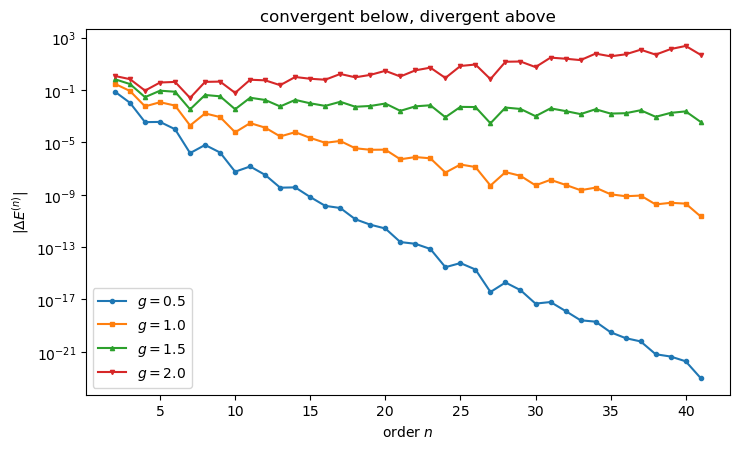

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for g, style in ((0.5, "-o"), (1.0, "-s"), (1.5, "-^"), (2.0, "-v")):
    part, _ = mbpt.pairing_partition(g=g)
    e = np.abs(np.array(mbpt.rayleigh_schrodinger(part, order=41)))
    n = np.arange(1, len(e) + 1)
    ax.semilogy(n[1:], np.maximum(e[1:], 1e-30), style, ms=3,
                label=f"$g = {g}$")
ax.set_xlabel("order $n$"); ax.set_ylabel(r"$|\Delta E^{(n)}|$")
ax.set_title("convergent below, divergent above")
ax.legend(); fig.tight_layout(); plt.show()

At $g=0.5$ and $g=1$ the terms fall away steadily.  At $g=2$ they grow without
limit.  The radius of convergence lies between — and crucially, **the first
three orders give no warning**: at $g=1.5$ they look perfectly reasonable.

## 4. The Lipkin model

Here $\Delta E^{(1)} = 0$ and $\Delta E^{(3)} = 0$, both identically, because
the interaction changes $J_z$ by exactly two units.  Second order is available
in closed form, $\Delta E^{(2)} = -N(N-1)V^2/4\varepsilon$.

In [7]:
mbpt.demo_lipkin()

4. The Lipkin model
N = 4, eps = 1, W = 0.  The interaction changes J_z by two units,
so the first-order energy vanishes and the reference energy is the
unperturbed -N eps / 2 = -2.  The RPA result of chapter 7 is
available in closed form, w = eps sqrt(1 - chi^2), which gives a
correlation energy to compare against.

   chi     E_ref          +E2          +E3        exact          RPA
  0.25  -2.00000  -2.02083333  -2.02083333  -2.02072594  -2.02109449
  0.50  -2.00000  -2.08333333  -2.08333333  -2.08166600  -2.08796735
  0.75  -2.00000  -2.18750000  -2.18750000  -2.17944947  -2.21691233
  0.90  -2.00000  -2.27000000  -2.27000000  -2.25388553  -2.35114625
  1.00  -2.00000  -2.33333333  -2.33333333  -2.30940108  -2.58578643

Second-order perturbation theory for this model is available in
closed form.  The interaction connects the reference only to the
state with two particles lifted, at an excitation energy 2 eps,
with the matrix element (V/2) sqrt(2 N (N-1)), so that
   Delta E^(2) = -

## 5. Size extensivity

Two identical, non-interacting copies of a three-level pairing system.  Any
acceptable method must give exactly twice the energy of one subsystem.
Rayleigh-Schrödinger is exact at every order; Brillouin-Wigner is not.

In [8]:
mbpt.demo_size_extensivity()

5. Size extensivity: Rayleigh-Schrodinger against Brillouin-Wigner
Two identical, non-interacting copies of a two-level pairing
system, the construction of chapter 5.  Any acceptable method must
give exactly twice the energy of one subsystem.

Each subsystem has three levels and one pair, so that the
third-order energy does not vanish trivially.

g = 0.25:
      order        2 x one     two copies       error
      first   -0.250000000   -0.250000000    0.00e+00
     second   -0.023437500   -0.023437500    0.00e+00
      third   -0.000976562   -0.000976562    0.00e+00
     fourth    0.000068665    0.000068665    0.00e+00
      BW(2)   -0.272184957   -0.271076650    1.11e-03

g = 0.5:
      order        2 x one     two copies       error
      first   -0.500000000   -0.500000000    0.00e+00
     second   -0.093750000   -0.093750000    0.00e+00
      third   -0.007812500   -0.007812500    0.00e+00
     fourth    0.001098633    0.001098633    0.00e+00
      BW(2)   -0.583666572   -0.57584

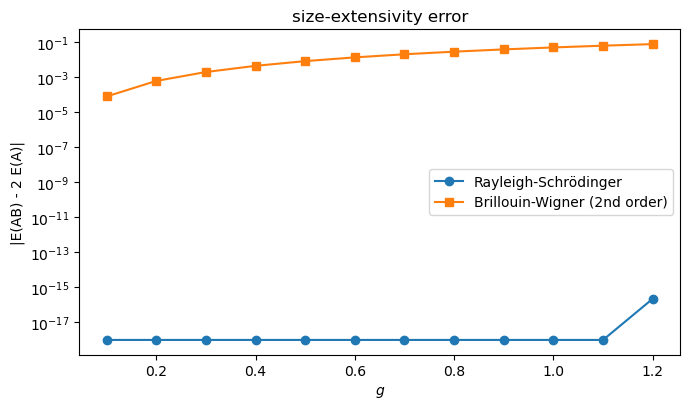

In [9]:
gs = np.linspace(0.1, 1.2, 12)
err_rs, err_bw = [], []
for g in gs:
    one = mbpt.IndependentPairing(subsystems=1, levels=3, g=g).partition()
    two = mbpt.IndependentPairing(subsystems=2, levels=3, g=g).partition()
    e1 = mbpt.rayleigh_schrodinger(one, order=3)
    e2 = mbpt.rayleigh_schrodinger(two, order=3)
    err_rs.append(abs(sum(e2) - 2 * sum(e1)))
    b1, _ = mbpt.brillouin_wigner(one, order=2)
    b2, _ = mbpt.brillouin_wigner(two, order=2)
    err_bw.append(abs(b2 - 2 * b1))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(gs, np.maximum(err_rs, 1e-18), "o-", label="Rayleigh-Schrödinger")
ax.semilogy(gs, err_bw, "s-", label="Brillouin-Wigner (2nd order)")
ax.set_xlabel("$g$"); ax.set_ylabel("|E(AB) - 2 E(A)|")
ax.set_title("size-extensivity error")
ax.legend(); fig.tight_layout(); plt.show()

## 6. Brillouin-Wigner and its exact resummation

$$\Delta E = \langle\Phi_0|\hat H_I
  + \hat H_I\hat Q\,[E-\hat H_0-\hat Q\hat H_I\hat Q]^{-1}\hat Q\hat H_I
  |\Phi_0\rangle$$

is not an approximation at all — solved self-consistently it must reproduce
the exact energy, and it does.

In [10]:
mbpt.demo_brillouin_wigner()

6. Brillouin-Wigner, and its exact resummation
Brillouin-Wigner puts the exact energy in the denominator, so the
equation must be solved self-consistently.  Its full resummation
   Delta E = <Phi_0| V + V Q [E - H_0 - Q V Q]^(-1) Q V |Phi_0>
is not an approximation at all, and must reproduce the exact
energy.  For the pairing model:

     g         BW(2)         BW(3)      BW exact           FCI  iterations
  0.25    1.73328927    1.73091635    1.73045985    1.73045985          41
  0.50    1.43866884    1.42314335    1.41677428    1.41677428          41
  1.00    0.79140813    0.70800963    0.63554847    0.63554847          36
  1.50    0.09433209   -0.10095126   -0.34819051   -0.34819051          27
  2.00   -0.63318105   -0.96772735   -1.48965216   -1.48965216          20

The last two columns agree to eight digits, as they must.  This
is worth pausing on: Brillouin-Wigner theory, resummed, is simply
a rewriting of the Schrodinger equation, exactly as the text says.
Its truncations 

## 7. The Hubbard model

Six sites at half filling in the momentum basis.  The third-order energy
vanishes identically here — special to this filling and this interaction, not
a general feature — so fourth order is shown as well.

In [11]:
mbpt.demo_hubbard()

7. The Hubbard model
Six sites at half filling in the momentum basis, where the
plane-wave determinant is the Hartree-Fock solution and the
first-order energy is the Hartree shift U N_up N_dn / L.

   U/t      E_ref          +E2          +E3          +E4          FCI          CID


   1.0   -6.50000  -6.60069444  -6.60069444  -6.60117251  -6.60115829  -6.59980159


   2.0   -5.00000  -5.40277778  -5.40277778  -5.41042685  -5.40945685  -5.38877703


   4.0   -2.00000  -3.61111111  -3.61111111  -3.73349623  -3.66870618  -3.41192866


   8.0    4.00000  -2.44444444  -2.44444444  -4.40260631  -2.04813089  -0.36779217

Two things stand out.  First, the third-order energy vanishes
identically at this filling -- the columns +E2 and +E3 are equal
to every digit, for every U.  That is special to the half-filled
ring with a momentum-independent interaction and is not a general
feature; the pairing model of section 2 has a perfectly good
third-order term.  Fourth order is not zero, so we have included
it.

Second, the series works beautifully at weak coupling -- at
U/t = 1 second order is already within two millihartree of the
exact value -- and collapses at strong coupling.  At U/t = 8 the
fourth-order term overshoots the exact energy by more than a
factor of two.  The reference determinant has stopped being a
good starting point, which is the strong-correlation regime of
chapter 5 seen through the perturbation series.


## 8. The pairing plus particle-hole model

The particle-hole term breaks pairs, so the reference couples to singles as
well as doubles.  We split the second-order sum by excitation rank.  The
singles piece would vanish identically in a Hartree-Fock basis.

In [12]:
mbpt.demo_pairing_ph()

8. The pairing plus particle-hole model of chapter 7
Here the particle-hole term breaks pairs, so the reference does
couple to singles and the second-order energy picks up a 1p-1h
contribution as well as the 2p-2h one.  We separate them.

     g       f      E_ref     E2(1p1h)     E2(2p2h)          +E2          +E3          FCI
  0.50   0.025    1.45000  -0.00072917  -0.08856250   1.36070833   1.34684681   1.34713265
  0.70   0.050    1.20000  -0.00291667  -0.18800000   1.00908333   0.96643444   0.96975878
  1.00   0.050    0.90000  -0.00291667  -0.35425000   0.54283333   0.43194111   0.45058234
  1.00   0.500    0.00000  -0.29166667  -1.30000000  -1.59166667  -2.25388889  -1.69173670

The singles contribution is small but not zero, and it would
vanish identically in a Hartree-Fock basis by Brillouin's theorem
-- which is exactly why one works in that basis.  For the three
weakly coupled rows the series behaves well, third order sitting
within a few parts in a thousand of the exact ans

## 9. Does the partition matter?

Nothing forced our choice of $\hat H_0$.  For three of the four models the
one-body and Epstein-Nesbet partitions give *identical* answers, because the
diagonal of $\hat H_I$ is constant over every determinant the reference can
reach.  Only the pairing plus particle-hole model distinguishes them.

In [13]:
mbpt.demo_partitions()

9. Does the partition matter?
Nothing forced our choice of H_0.  Taking the whole diagonal of H
instead of the one-body part gives the Epstein-Nesbet partition,
in which the first-order energy vanishes by construction and the
denominators contain the diagonal of the interaction as well.

For three of our four models the two partitions give identical
results, and it is worth seeing why: the diagonal of V is the
same on every determinant the reference can reach, so the two
choices of H_0 differ by a constant, which cancels in every
energy denominator.

         model   spread of diag(V)


       pairing            1.000000
        Lipkin            0.000000
       Hubbard            0.000000
 pairing + p-h            2.000000

Only the pairing plus particle-hole model has a genuinely varying
diagonal, because the particle-hole term contributes -f per
complete pair and the number of complete pairs differs from one
determinant to the next.  There the two partitions do disagree:

    g      f   one-body: +E2          +E3     E-N: +E2          +E3          FCI


 0.50   0.25      0.60208333   0.51930556   0.62435065   0.51885823   0.55119157
 1.00   0.50     -1.59166667  -2.25388889  -1.44791667  -2.25694444  -1.69173670
 1.50   0.75     -4.58125000  -6.81625000  -4.17225275  -6.82273352  -4.34336785

Both partitions sum to the same exact answer, but at any finite
order they disagree, and neither is uniformly better: at second
order Epstein-Nesbet wins the last row and loses the first two,
and at third order the two are almost indistinguishable and both
are very poor.  There is no theorem saying one partition is
better than another.  The choice is part of the approximation, and
quoting a perturbative number without saying which partition
produced it is meaningless.


## 10. Everything against everything

In [14]:
mbpt.demo_comparison()

10. Everything against everything
The pairing model with four levels and four particles, the one
system every chapter has now treated.

     g         HF       MBPT2       MBPT3         CID      HF+RPA         FCI
  0.25    1.75000    1.731771    1.730469    1.730507    1.716347    1.730460


  0.50    1.50000    1.427083    1.416667    1.417596    1.374502    1.416774


  1.00    1.00000    0.708333    0.625000    0.648907    0.554589    0.635548
  1.50    0.50000   -0.156250   -0.437500   -0.291132   -0.406248   -0.348191
  2.00    0.00000   -1.166667   -1.833333   -1.352087   -1.476223   -1.489652

The same table as errors, which is where the interest lies:
     g       MBPT2       MBPT3         CID      HF+RPA
  0.25    1.31e-03    8.90e-06    4.72e-05   -1.41e-02
  0.50    1.03e-02   -1.08e-04    8.22e-04   -4.23e-02
  1.00    7.28e-02   -1.05e-02    1.34e-02   -8.10e-02
  1.50    1.92e-01   -8.93e-02    5.71e-02   -5.81e-02
  2.00    3.23e-01   -3.44e-01    1.38e-01    1.34e-02

Hartree-Fock does nothing at all, since the pairing interaction
cannot couple the reference to a 1p-1h state.  Beyond that the
ordering changes with the coupling, and no method wins
everywhere.  At g = 0.25 third-order perturbation theory is best
by three orders of magnitude and RPA is the worst of the four.
At g = 2 the ordering has reversed completely: RPA is best, and


## The full program

Everything above lives in `BookManybody/BookPrograms/chapter09/mbpt.py`, which
runs as a script and prints all ten demonstrations of the chapter.

In [15]:
print(open(mbpt.__file__).read())

"""
Many-body perturbation theory: Rayleigh-Schrodinger and Brillouin-Wigner.

Companion code to chapter 9 of *Quantum mechanics for Many-particle Systems*.

Everything is done in the determinant basis of chapter 5, where the
unperturbed Hamiltonian is diagonal and the perturbation is the rest of the
matrix.  Writing R = Q / (W_0 - H_0) for the resolvent, the Rayleigh-
Schrodinger series is generated by the standard recursion

    psi^(n)   = R [ V psi^(n-1) - sum_{k=1}^{n-1} E^(k) psi^(n-k) ] ,
    E^(n+1)   = <Phi_0| V |psi^(n)> ,

which reproduces the explicit first, second and third order expressions of
the text and continues to any order.  Brillouin-Wigner uses the exact energy
in the denominator instead and is solved self-consistently; its full
resummation is exact and reproduces the configuration-interaction energy.

Four models are treated, all of them met earlier in the book:

    pairing            chapters 4 and 5
    Lipkin             chapters 4, 6 and 7
    Hubbard       